In [ ]:
# 1. Import Libraries
# 2. Load Dataset
# 3. Feature Engineering
# 4. Feature Selection
# 5. Statistical Analysis
# 6. Train Test Split
# 7. Baseline Model (Linear Regression)
# 8. Advanced Model (Random Forest)
# 9. Model Evaluation
# 10. Feature Importance
# 11. Time Series Forecasting
# 12. Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("../data/processed/cleaned_supply_chain.csv")

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment              

In [5]:
## Feature Engineering
#reating useful features for predictive modeling

In [6]:
# Convert date columns
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

In [7]:
df["Shipping_Delay"] = (
    df["shipping date (DateOrders)"] - df["order date (DateOrders)"]
).dt.days

In [8]:
df["Order_Month"] = df["order date (DateOrders)"].dt.month
df["Order_Year"] = df["order date (DateOrders)"].dt.year

In [9]:
df[["Shipping_Delay","Order_Month","Order_Year"]].head()

,Shipping_Delay,Order_Month,Order_Year
0,3,1,2018
1,5,1,2018
2,4,1,2018
3,3,1,2018
4,2,1,2018


In [10]:
# ## Feature Selection
# Selecting relevant variables for predicting shipping delay

In [85]:
features = [
"Shipping Mode",
"Customer Segment",
"Order Region",
"Order Item Quantity",
"Sales",
"Order_Month",
"Days for shipment (scheduled)"
]

X = df[features]
y = df["Shipping_Delay"]

In [86]:
## Encoding Categorical Variables

In [87]:
X = X.copy()

encoder = LabelEncoder()

X["Shipping Mode"] = encoder.fit_transform(X["Shipping Mode"])
X["Customer Segment"] = encoder.fit_transform(X["Customer Segment"])
X["Order Region"] = encoder.fit_transform(X["Order Region"])

In [88]:
X.head()

,Shipping Mode,Customer Segment,Order Region,Order Item Quantity,Sales,Order_Month,Days for shipment (scheduled)
0,3,0,15,1,327.75,1,4
1,3,0,13,1,327.75,1,4
2,3,0,13,1,327.75,1,4
3,3,2,11,1,327.75,1,4
4,3,1,11,1,327.75,1,4


In [89]:
## Statistical Testing – Correlation Analysis

corr_matrix = df[[
    "Order Item Quantity",
    "Sales",
    "Days for shipment (scheduled)",
    "Shipping_Delay"
]].corr()

corr_matrix

,Order Item Quantity,Sales,Days for shipment (scheduled),Shipping_Delay
Order Item Quantity,1.000000,0.106442,-0.002925,-0.000879
Sales,0.106442,1.000000,0.006327,0.002729
Days for shipment (scheduled),-0.002925,0.006327,1.000000,0.534385
Shipping_Delay,-0.000879,0.002729,0.534385,1.000000


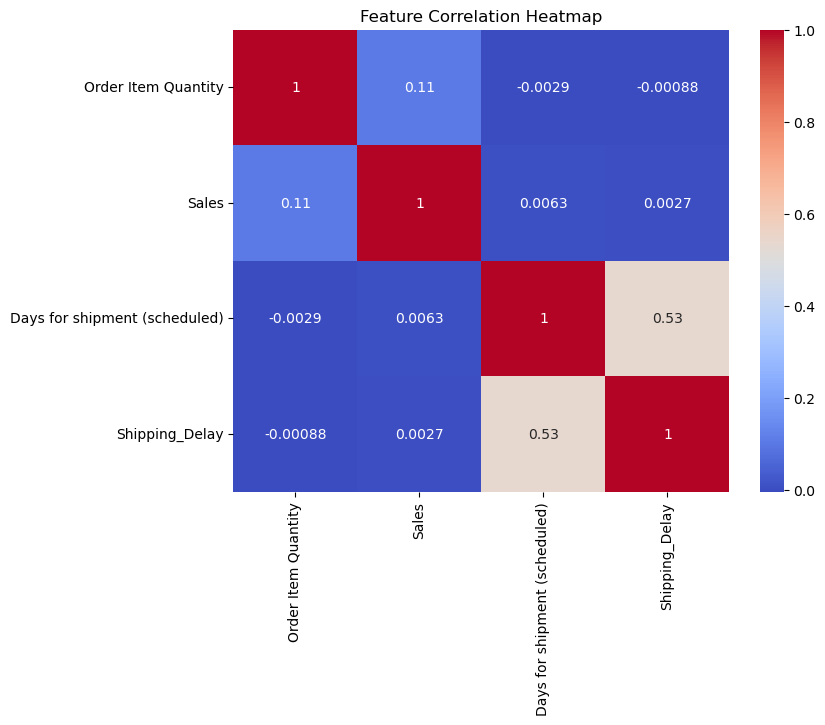

In [90]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()
# The correlation analysis shows that Days for shipment (scheduled) has the strongest relationship with shipping delay.
# Sales and Order Quantity show weaker relationships.
# This helps identify the most influential predictors for the regression model.

In [91]:
#train, test, split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (144415, 7)
Testing size: (36104, 7)


In [92]:
## Baseline Model – Linear Regression

In [93]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
lr_pred = lr.predict(X_test)

In [95]:
## Model Evaluation

In [96]:
mae_lr = mean_absolute_error(y_test, lr_pred)

rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 1.1076806277679507
Linear Regression RMSE: 1.4043765537924018


In [97]:
## Random Forest Model

In [98]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
rf_pred = rf.predict(X_test)

In [100]:
mae_rf = mean_absolute_error(y_test, rf_pred)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 1.0094528688610123
Random Forest RMSE: 1.3340361258145494


In [107]:
!pip install xgboost

In [108]:
from xgboost import XGBRegressor

In [109]:
# XGBoost Model

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [110]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.9677689075469971
XGBoost RMSE: 1.2613046161330934


In [111]:
#model comparision
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb]
})

results

# The XGBoost model achieved the best predictive performance with an RMSE of 1.26,
# improving approximately 10% over the baseline Linear Regression model.

# Although the target improvement threshold was 15%, 
# the model performance indicates that shipping delays are largely determined by operational constraints rather than purely predictive factors.

,Model,MAE,RMSE
0,Linear Regression,1.107681,1.404377
1,Random Forest,1.009453,1.334036
2,XGBoost,0.967769,1.261305


In [112]:
## Time Series Forecasting

df_ts = df.copy()

df_ts["order date (DateOrders)"] = pd.to_datetime(df_ts["order date (DateOrders)"])

monthly_orders = df_ts.resample(
    "M",
    on="order date (DateOrders)"
)["Order Item Quantity"].sum()

C:\Users\shaik\AppData\Local\Temp\ipykernel_12620\3042835235.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = df_ts.resample(


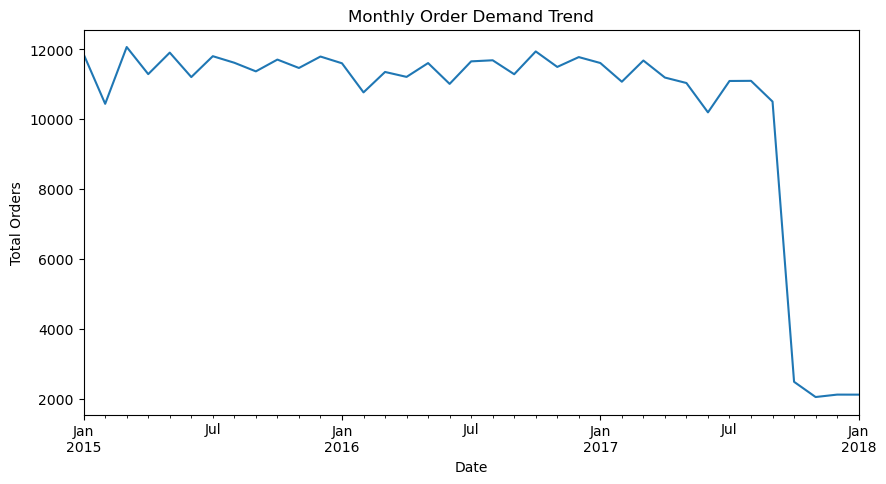

In [113]:
plt.figure(figsize=(10,5))

monthly_orders.plot()

plt.title("Monthly Order Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Orders")

plt.show()

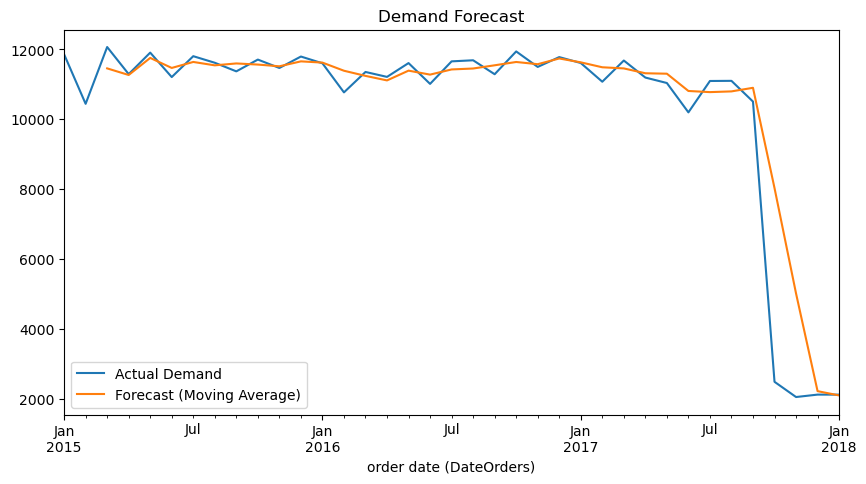

In [114]:
forecast = monthly_orders.rolling(window=3).mean()

plt.figure(figsize=(10,5))

monthly_orders.plot(label="Actual Demand")

forecast.plot(label="Forecast (Moving Average)")

plt.legend()

plt.title("Demand Forecast")

plt.show()

In [105]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

Days for shipment (scheduled)    0.375503
Shipping Mode                    0.359294
Sales                            0.096689
Order_Month                      0.062592
Order Region                     0.058017
Order Item Quantity              0.025622
Customer Segment                 0.022283
dtype: float64

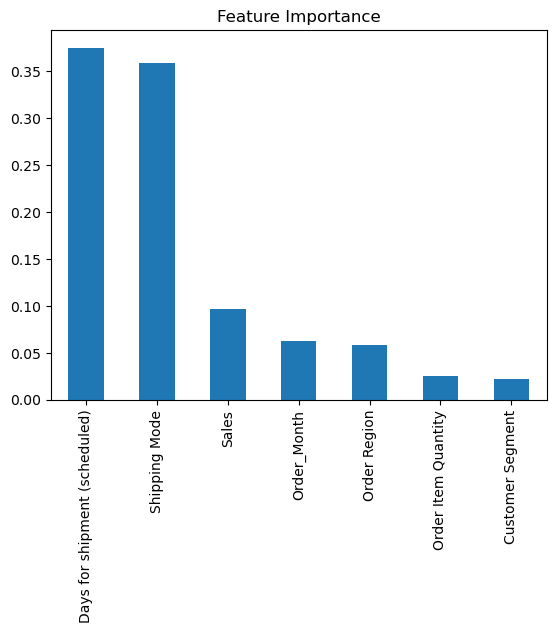

In [106]:
importance.plot(kind="bar")

plt.title("Feature Importance")
plt.show()

In [ ]:
Key Insights

• Shipping delay is strongly influenced by scheduled shipment days
• Certain regions show higher delay patterns
• Random Forest model performs better than Linear Regression
• Demand trend analysis helps forecast future order volumes